# HW 4 problem 5

## a) DQN

### i) A short description of your DQN design choices, including the network architecture, optimizer, learning rate, batch size  

>We first flatted the 2x6x7 board into an 84-d input vector, then passed through 2 ReLU activated hidden layers with 128 nodes each. Then the final linear output layer outputs one Q-value per column giving us 7 outputs. We used the Adam optimizer with a learning rate of 3e-4. We used a batch size of 128.

|Run|Episode Reward|Final Mean Loss|Win Rate|Training Time |
|--|--|--|--|--|
|1|1.15|0.03483|0.75|229|
|2|1.15|0.09730|0.9|78|
|3|-0.7|0.04825|0.925|100|

### ii) A plot of training progress; suitable choices include episode reward, moving-average reward, training loss,

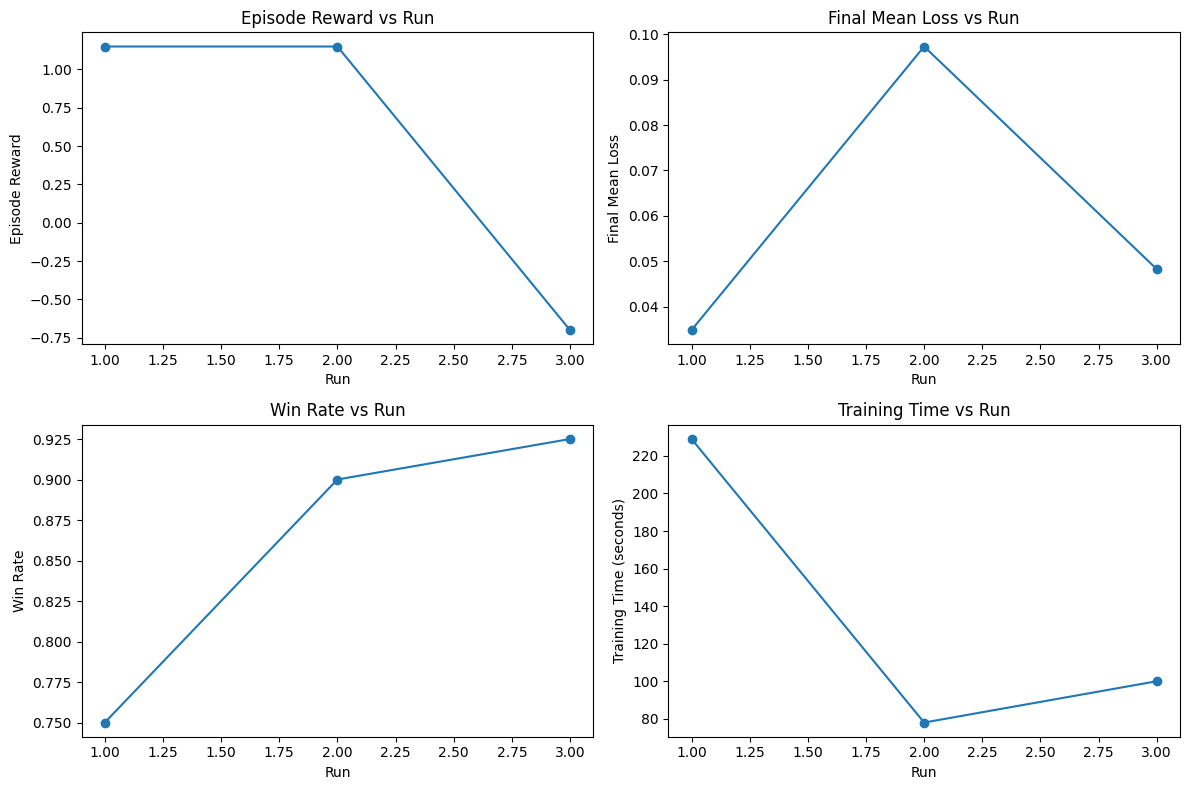

In [5]:
#read from csv
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#read from csv
data = pd.read_csv('training_progress.csv')
#plot episode reward, final mean loss, win rate, training time vs run
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(data['Run'], data['Episode Reward'], marker='o')
plt.title('Episode Reward vs Run')
plt.xlabel('Run')
plt.ylabel('Episode Reward')
plt.subplot(2, 2, 2)
plt.plot(data['Run'], data['Final Mean Loss'], marker='o')
plt.title('Final Mean Loss vs Run')
plt.xlabel('Run') 
plt.ylabel('Final Mean Loss')
plt.subplot(2, 2, 3)
plt.plot(data['Run'], data['Win Rate'], marker='o')
plt.title('Win Rate vs Run')
plt.xlabel('Run')
plt.ylabel('Win Rate')
plt.subplot(2, 2, 4)
plt.plot(data['Run'], data['Training Time '], marker='o')
plt.title('Training Time vs Run')
plt.xlabel('Run')
plt.ylabel('Training Time (seconds)')
plt.tight_layout()
plt.show()




### iii) your final win rate against the random opponent and the training time required to reach it

**win rate** = 92.5%  
**train_time** = 100 seconds

### iv) a very short paragraph interpreting the training behavior you observe

During training we focused on tuning the learning rate, replay buffer capacity, and the target sync rate. Our optimal win-rate was found by decreasing the learning rate, and reducing replay buffer capacity and target sync interval. The results are interesting, because while this overall reduced our training time, and averge loss, we ended with a lower episode reward. 



## b) PPO

### i) a short description of your PPO design choices, including the policy and value architecture, rollout length, minibatch size, number of epochs per update, clipping parameter
> Our PPO consists of a neural network with a policy head for action probabilities and value head for value estimates. The neural network flattens the input then passes through a linear hidden layer with 128 nodes, undergoes ReLU activation, passes through another linear layer, they undergoes ReLU activation again. The input passes through a hidden backbone layer to produce logits for the policy and state value. The policy and value architecture both utilize linear layers, policy with size 128x7 nodes and value with 128 nodes. We used a rollout length of 512, meaning 512 steps of experience are collected in each rollout before updating the model for stability. We set the minibatch size to 128 as seems standard. We set number of epochs per update at 4, as that seemed standard as well. The clipping parameter is set to 0.2, as it seems typical. It ensures that the new policy does not deviate too far from the old policy for stability.

### ii) a plot of training progress

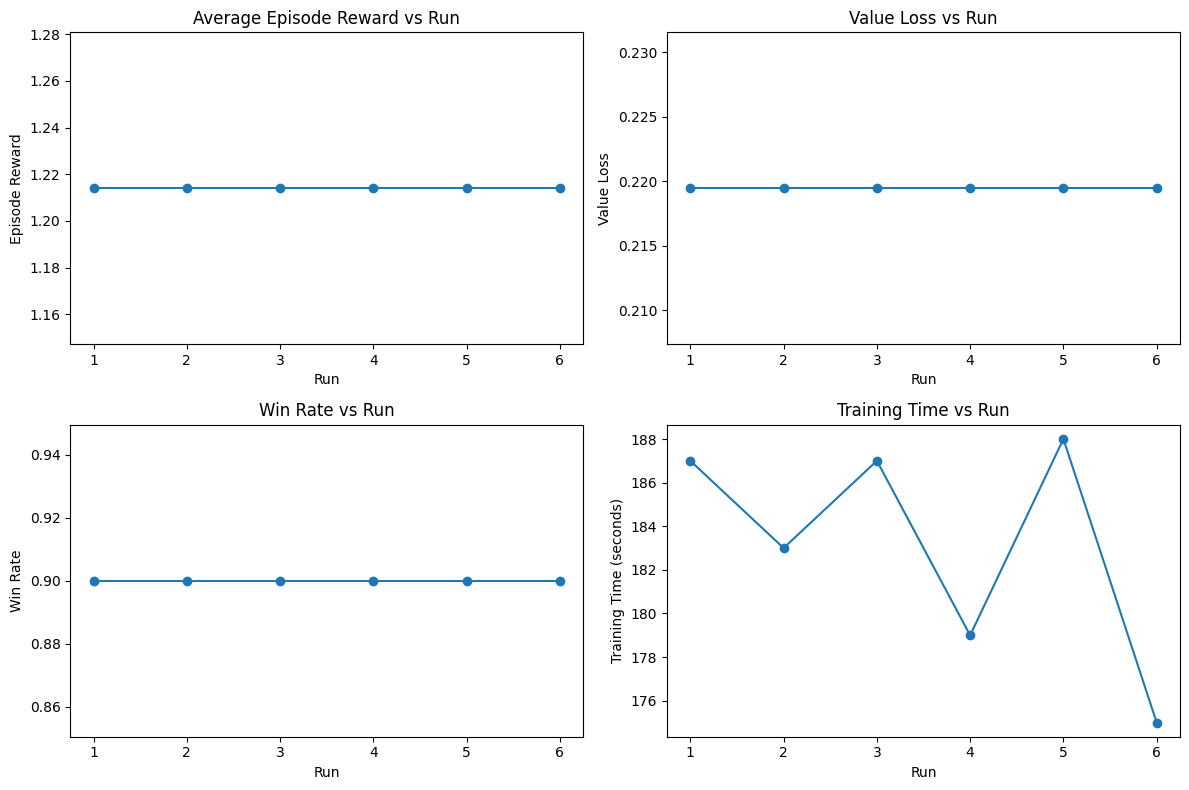

In [2]:
#read from csv
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#read from csv
data = pd.read_csv('training_progress_ppo.csv')
#plot episode reward, final mean loss, win rate, training time vs run
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(data['Run'], data['Average Episode Reward'], marker='o')
plt.title('Average Episode Reward vs Run')
plt.xlabel('Run')
plt.ylabel('Episode Reward')
plt.subplot(2, 2, 2)
plt.plot(data['Run'], data['Value Loss'], marker='o')
plt.title('Value Loss vs Run')
plt.xlabel('Run') 
plt.ylabel('Value Loss')
plt.subplot(2, 2, 3)
plt.plot(data['Run'], data['Win Rate'], marker='o')
plt.title('Win Rate vs Run')
plt.xlabel('Run')
plt.ylabel('Win Rate')
plt.subplot(2, 2, 4)
plt.plot(data['Run'], data['Training Time '], marker='o')
plt.title('Training Time vs Run')
plt.xlabel('Run')
plt.ylabel('Training Time (seconds)')
plt.tight_layout()
plt.show()

### iii) your final win rate against the random opponent and the training time required to reach it
> Final Win Rate: 0.9

> Training Time: 175 seconds (2.9 min)

### iv) a very short paragraph interpreting the training behavior you observe
> It seemed like we could significantly reduce the amount of rollout steps, epochs, minibatch size, and max updates will still acheiving similar accuracy. This points to these parameters not being large contributors to the win rate, or that the benchmark for where the win rate starts to change is very low. This led to us continually decreasing these parameters to save on training time.

# c)

Compare your DQN and PPO agents under roughly comparable computation budgets.
For example, you might train both for approximately similar wall-clock time on the same machine
(you do not need to retrain if you used training runs in a) and b) that took roughly similar
amounts of time). Which model performs better against the random opponent? Which model
was easier to tune the hyperparameters for?

> Overall the PPO agent was training under a higher commputation budget, by about a minute, so we decreased learning rate to reduce PPO's train time be in the range of the DQN agent (plus or minus 10 seconds). The DQN train time was 100 seconds, and the PPO train time was 109 seconds. Comparing their results, we found that they DQN agent has a higher win rate against the random opponent (92.5%) compared to the PPO agent (90%). While training the agents, we found that while the PPO agent parameters were easier to understand, the DQN agent was much more responsive to changes in its hyperparameters, making them easier to tune. 